In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
img_paths = [
    "/content/drive/MyDrive/content/img1.jpg",
    "/content/drive/MyDrive/content/img2.jpg",
    "/content/drive/MyDrive/content/img3.jpg",
    "/content/drive/MyDrive/content/img4.jpg"
]

Отобраны 3 open-source библиотеки: DeepFace, InsightFace, Face Recognition



DeepFace

Ссылка: GitHub: https://github.com/serengil/deepface

Возможности:
-	Поддержка 6 моделей: VGG-Face, Facenet, OpenFace, DeepFace, Dlib, ArcFace
-	Распознавание, демография, эмоции, возраст
-	Простое сравнение двух изображений

Преимущества:

-	Много моделей из коробки
-	Встроенная визуализация
-	Можно переключать backend

Требования:

- PyTorch / TensorFlow / MXNet — в зависимости от backend
- Поддержка CUDA (опционально)


Тестируем Deepface

In [ ]:
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=c9463c9330b2408f69e0eeee64aa633adf9814a029814ef902698f1f034d8ff3
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


Извлекаем все лица с каждого изображения и сохраняем их в all_faces

In [ ]:
from deepface import DeepFace

img_paths = [
    "/content/drive/MyDrive/content/img1.jpg",
    "/content/drive/MyDrive/content/img2.jpg",
    "/content/drive/MyDrive/content/img3.jpg",
    "/content/drive/MyDrive/content/img4.jpg"
]

all_faces = []

for idx, path in enumerate(img_paths):
    faces = DeepFace.extract_faces(
        path,
        detector_backend="opencv",
        align=True,
        enforce_detection=False
    )
    for i, face_obj in enumerate(faces):
        all_faces.append({
            "img_index": idx + 1,
            "face_index": i + 1,
            "face": face_obj["face"]
        })

Показываем все найденные лица по одному с подписями

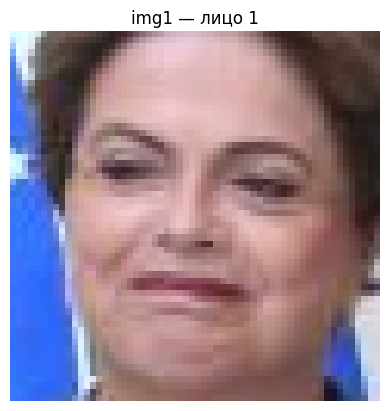

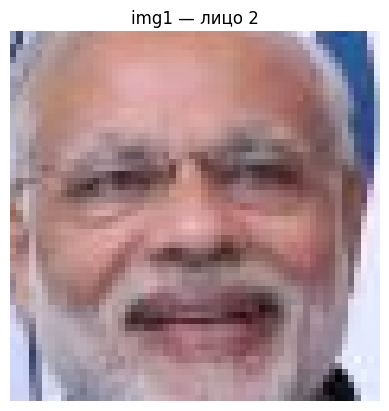

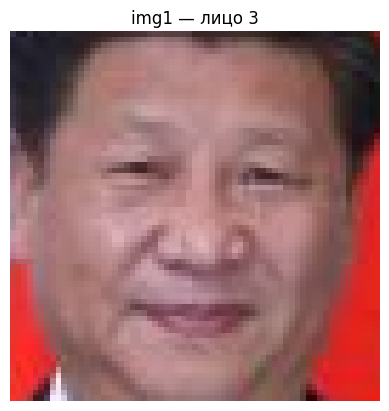

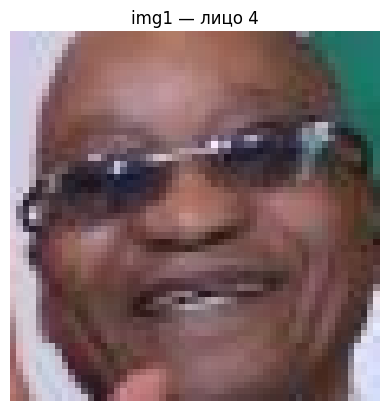

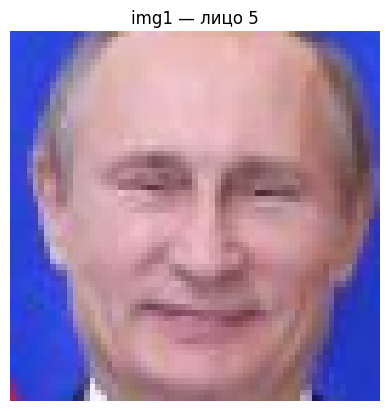

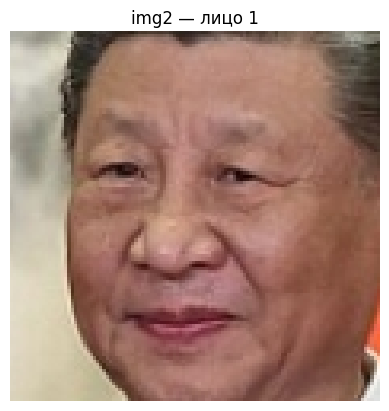

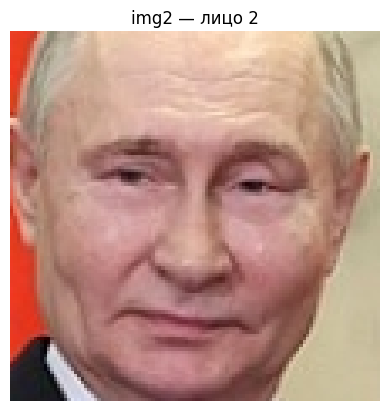

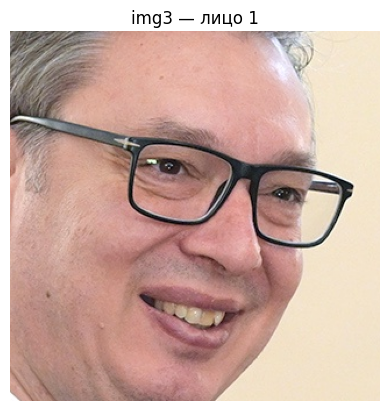

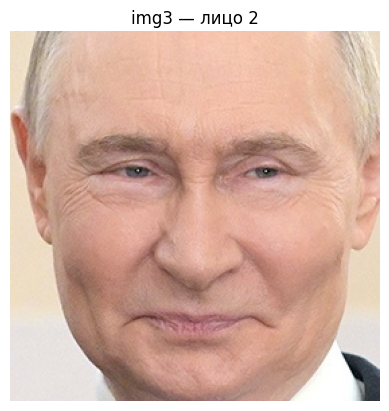

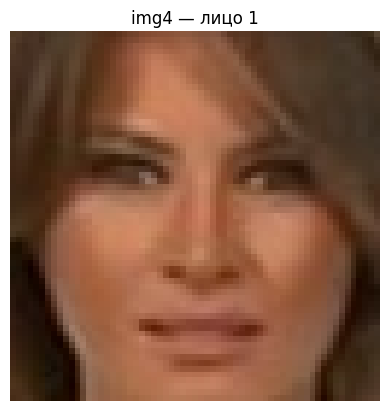

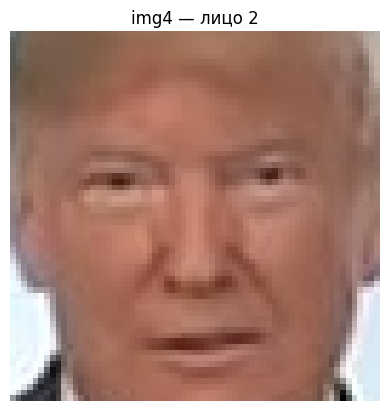

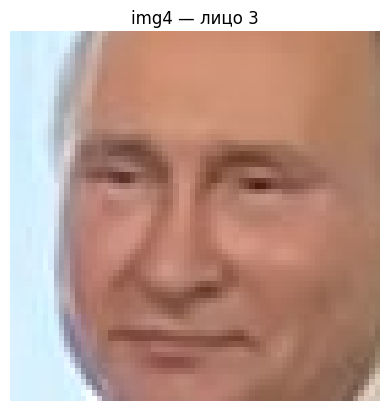

In [ ]:
import matplotlib.pyplot as plt

for f in all_faces:
    plt.imshow(f["face"])
    plt.title(f"img{f['img_index']} — лицо {f['face_index']}")
    plt.axis("off")
    plt.show()

Сохраняем каждое лицо как отдельный JPEG-файл во временную папку

In [ ]:
import os
import numpy as np
import cv2

temp_dir = "/content/deepface_faces"
os.makedirs(temp_dir, exist_ok=True)

for f in all_faces:
    img_arr = np.array(f["face"])
    if img_arr.dtype != np.uint8:
        img_arr = (np.clip(img_arr, 0, 1) * 255).astype(np.uint8)
    if img_arr.shape[2] != 3:
        img_arr = img_arr[:, :, :3]
    fname = f"img{f['img_index']}_face{f['face_index']}.jpg"
    f["temp_path"] = os.path.join(temp_dir, fname)
    cv2.imwrite(f["temp_path"], cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR))

Получаем эмбеддинги лиц через DeepFace с моделью ArcFace (векторные представления для сравнения), печатаем первые 5 значений эмбеддинга (для краткости)


In [ ]:
from deepface import DeepFace
import numpy as np

for f in all_faces:
    rep = DeepFace.represent(
        img_path=f["temp_path"],
        model_name="ArcFace",
        enforce_detection=False
    )
    f["embedding"] = rep[0]["embedding"]

    print(f"img{f['img_index']} лицо {f['face_index']} → embedding[:5] = {np.round(f['embedding'][:5], 4)} ...")

img1 лицо 1 → embedding[:5] = [ 0.0212  0.1398  0.0511 -0.4132 -0.1467] ...
img1 лицо 2 → embedding[:5] = [-0.1173 -0.0249  0.0249 -0.326  -0.0575] ...
img1 лицо 3 → embedding[:5] = [ 0.0897 -0.194  -0.0804 -0.071  -0.0587] ...
img1 лицо 4 → embedding[:5] = [-0.0562 -0.2053 -0.1206 -0.0761 -0.1431] ...
img1 лицо 5 → embedding[:5] = [-0.0543  0.2961 -0.0226 -0.3109  0.118 ] ...
img2 лицо 1 → embedding[:5] = [-0.0134 -0.117  -0.0274  0.4542 -0.0664] ...
img2 лицо 2 → embedding[:5] = [-0.0766 -0.0319 -0.1019 -0.0386 -0.0748] ...
img3 лицо 1 → embedding[:5] = [ 0.0095  0.2279  0.0997 -0.0368 -0.1255] ...
img3 лицо 2 → embedding[:5] = [-0.1234  0.2687 -0.1069 -0.0493 -0.2744] ...
img4 лицо 1 → embedding[:5] = [-0.0246 -0.1418 -0.1028  0.2657  0.0134] ...
img4 лицо 2 → embedding[:5] = [-0.0043  0.1898 -0.0582 -0.1274 -0.0573] ...
img4 лицо 3 → embedding[:5] = [ 0.0244 -0.1582  0.0235 -0.0782 -0.1049] ...


Определяем похожие пары и выводим на экран

Взято завышенное значение threshold = 4.5, чтобы выводить совпадения и не совпадения. Чтобы были только совпадения, параметр threshold нужно уменьшить до 3.0

Для каждой пары извлекаем эмбеддинги, считаем эвклидово расстояние и проверяем разницу.



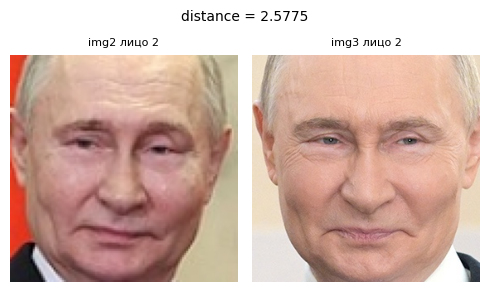

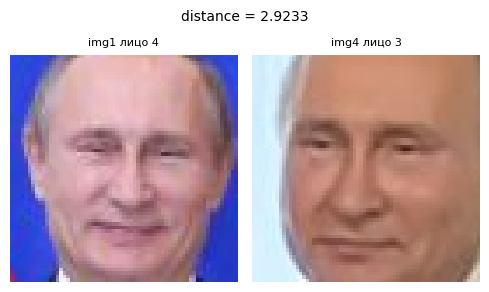

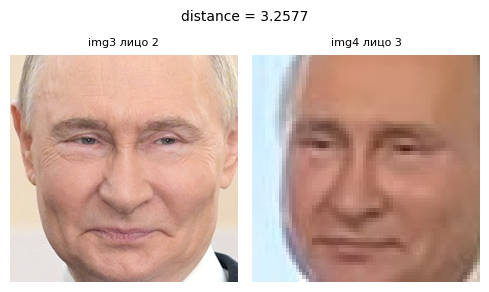

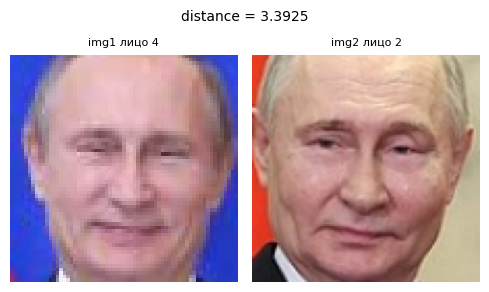

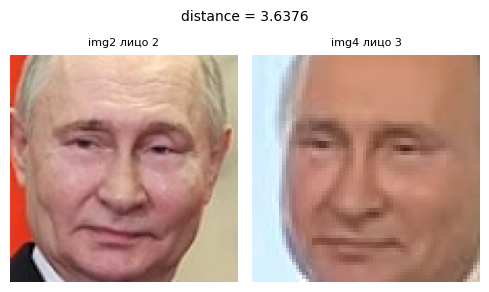

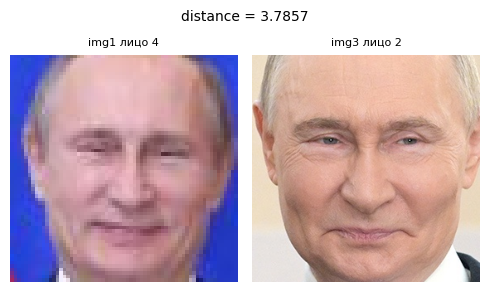

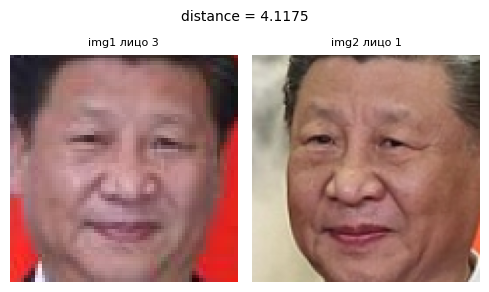

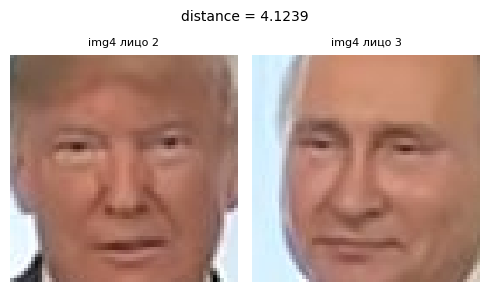

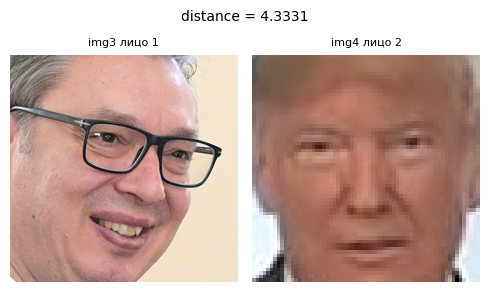

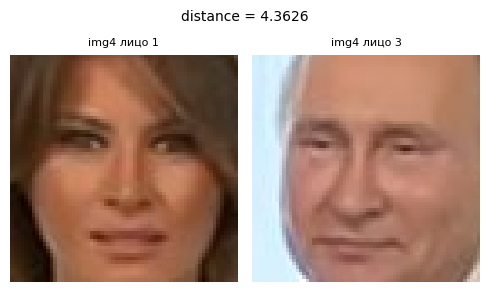

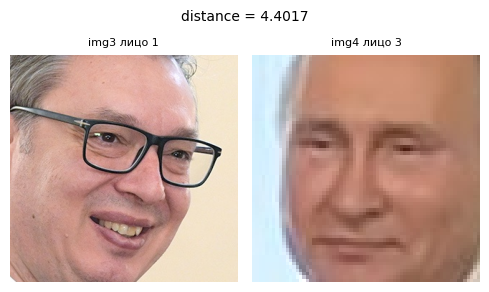

In [ ]:
from numpy.linalg import norm
import matplotlib.pyplot as plt
import numpy as np

threshold = 4.5

similar_pairs = []
for i in range(len(all_faces)):
    for j in range(i + 1, len(all_faces)):
        e1 = np.array(all_faces[i]["embedding"])
        e2 = np.array(all_faces[j]["embedding"])
        dist = norm(e1 - e2)
        if dist < threshold:
            similar_pairs.append((i, j, dist))

for i, j, dist in sorted(similar_pairs, key=lambda x: x[2]):
    face1 = all_faces[i]["face"]
    face2 = all_faces[j]["face"]
    label1 = f"img{all_faces[i]['img_index']} лицо {all_faces[i]['face_index']}"
    label2 = f"img{all_faces[j]['img_index']} лицо {all_faces[j]['face_index']}"

    fig, axs = plt.subplots(1, 2, figsize=(5, 3))
    axs[0].imshow(face1)
    axs[0].axis("off")
    axs[0].set_title(label1, fontsize=8)

    axs[1].imshow(face2)
    axs[1].axis("off")
    axs[1].set_title(label2, fontsize=8)

    plt.suptitle(f"distance = {dist:.4f}", fontsize=10)
    plt.tight_layout()
    plt.show()

Тестирование библиотеки DeepFace успешно завершено

InsightFace

Ссылка: GitHub: https://github.com/deepinsight/insightface

Возможности:

-    Поддержка SOTA моделей: ArcFace, CurricularFace, CosFace и др
-    Быстрый inference с использованием MXNet, ONNX, PyTorch.
-    Простое сравнение двух изображений
-    Выделение эмбеддингов, выравнивание лиц; распознавание, верификация и кластеризация

Преимущества:

-    Высокая точность (используется в NIST benchmark)
-    Поддержка FP16 и ONNX Runtime для ускорения
-    Самая популярная библиотека в академической среде

Требования:

- CUDA для ускорения (желательно)
- ONNX Runtime или PyTorch
- Работает на CPU, но медленно

Тестируем Insightface

In [ ]:
!pip install -q insightface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 75.4 MB/s eta 0:00:00


In [ ]:
!pip install -q onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.5 MB/s eta 0:00:00


Извлекаем все лица с каждого изображения и сохраняем их в all_faces

In [ ]:
from insightface.app import FaceAnalysis
import cv2

img_paths = [
    "/content/drive/MyDrive/content/img1.jpg",
    "/content/drive/MyDrive/content/img2.jpg",
    "/content/drive/MyDrive/content/img3.jpg",
    "/content/drive/MyDrive/content/img4.jpg"
]

app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

all_faces = []

for idx, path in enumerate(img_paths):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    faces = app.get(img_rgb)

    for i, face in enumerate(faces):
        x1, y1, x2, y2 = map(int, face.bbox)
        face_crop = img_rgb[y1:y2, x1:x2]

        all_faces.append({
            "img_index": idx + 1,
            "face_index": i + 1,
            "face": face_crop,
            "face_obj": face
        })

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

Показываем все найденные лица по одному с подписями

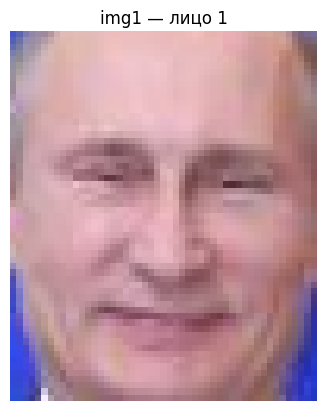

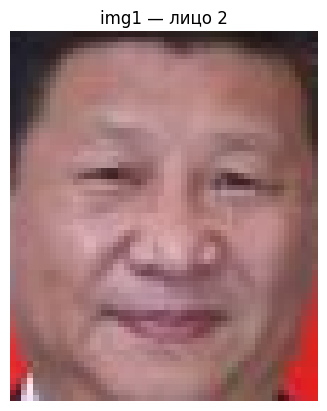

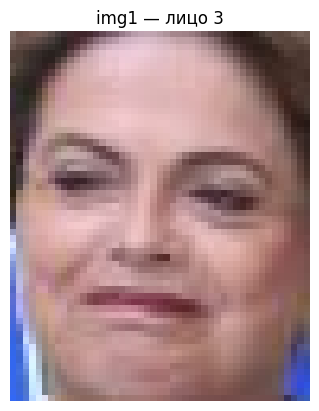

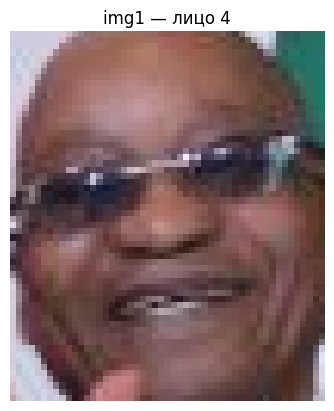

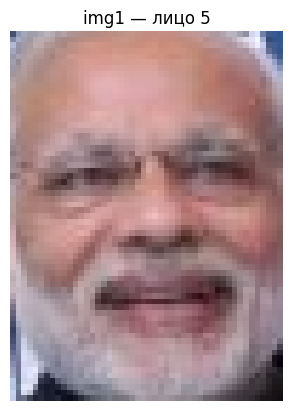

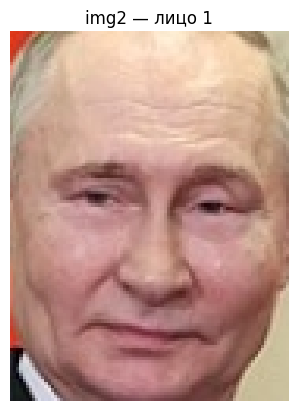

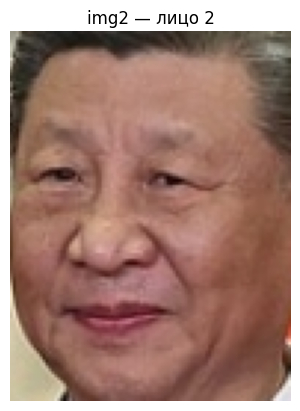

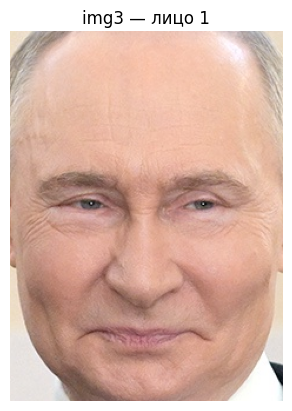

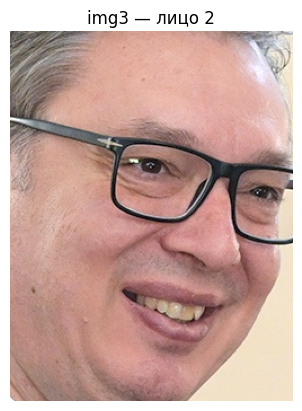

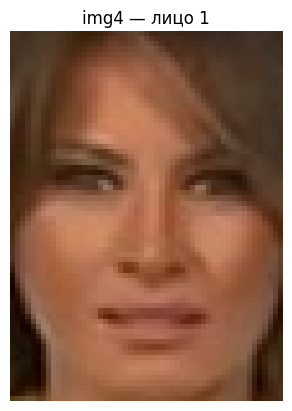

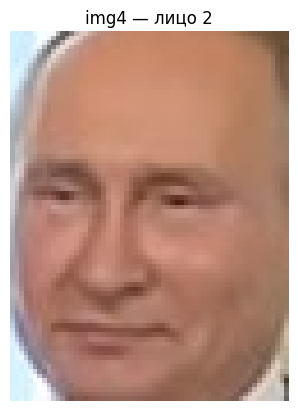

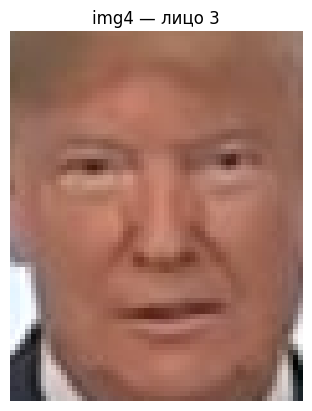

In [ ]:
import matplotlib.pyplot as plt

for f in all_faces:
    plt.imshow(f["face"])
    plt.title(f"img{f['img_index']} — лицо {f['face_index']}")
    plt.axis("off")
    plt.show()

Сохраняем каждое лицо как отдельный JPEG-файл во временную папку

In [ ]:
import os
import numpy as np
import cv2

temp_dir = "/content/insightface_faces"
os.makedirs(temp_dir, exist_ok=True)

for f in all_faces:
    img_arr = np.array(f["face"])
    if img_arr.dtype != np.uint8:
        img_arr = (np.clip(img_arr, 0, 1) * 255).astype(np.uint8)
    if img_arr.shape[2] != 3:
        img_arr = img_arr[:, :, :3]

    fname = f"img{f['img_index']}_face{f['face_index']}.jpg"
    f["temp_path"] = os.path.join(temp_dir, fname)
    cv2.imwrite(f["temp_path"], cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR))

Получаем эмбеддинги лиц

In [ ]:
import numpy as np

for f in all_faces:
    embedding = f["face_obj"].embedding
    f["embedding"] = embedding
    print(f"img{f['img_index']} лицо {f['face_index']} → embedding[:5] = {np.round(embedding[:5], 4)} ...")

img1 лицо 1 → embedding[:5] = [-1.4615  0.7452 -1.0593 -0.6831  1.9299] ...
img1 лицо 2 → embedding[:5] = [ 0.6194  0.0125 -0.7923  0.156   0.8965] ...
img1 лицо 3 → embedding[:5] = [ 0.61   -0.5676 -1.7143 -0.4703  0.0537] ...
img1 лицо 4 → embedding[:5] = [-2.0973  0.4978 -3.7183 -2.1001 -0.181 ] ...
img1 лицо 5 → embedding[:5] = [-0.1162  0.9855  2.5546 -0.5008 -0.5902] ...
img2 лицо 1 → embedding[:5] = [-0.5368 -0.2455 -0.5202 -2.8051  0.1665] ...
img2 лицо 2 → embedding[:5] = [-0.3573 -0.1031  0.434   0.3764  1.2029] ...
img3 лицо 1 → embedding[:5] = [-0.5714  0.2035 -0.2455 -3.0927  0.9007] ...
img3 лицо 2 → embedding[:5] = [ 1.6930e-01  1.9215e+00 -8.0000e-04  9.1920e-01  9.7440e-01] ...
img4 лицо 1 → embedding[:5] = [-0.3555 -1.2599  0.8652  0.6342  1.0524] ...
img4 лицо 2 → embedding[:5] = [-0.3824  0.9403 -0.856  -2.3749  1.2136] ...
img4 лицо 3 → embedding[:5] = [-0.5273 -1.4098  0.4158  3.2416  0.8374] ...


Определяем похожие пары и выводим на экран

Предварительно осуществляется нормализация эмбеддингов. Порог treshold завышен, чтобы были видны и совпадения, и не совпадения. При значении treshhod=1.0. будут только совпадения.

Найдено похожих пар: 12


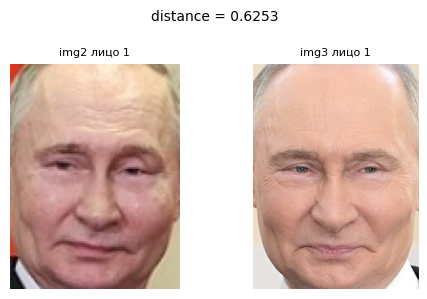

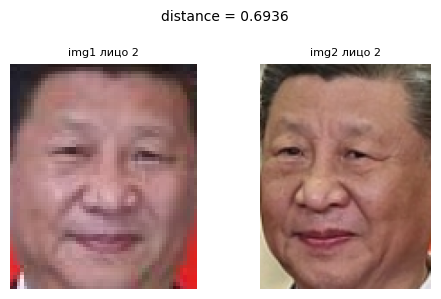

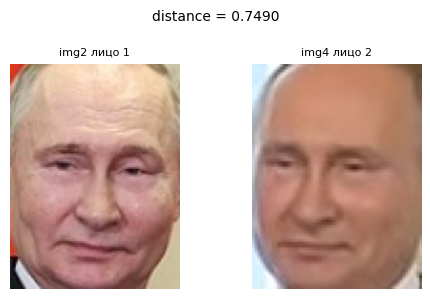

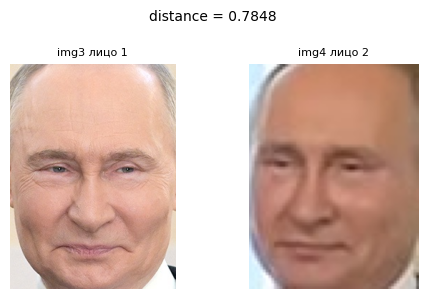

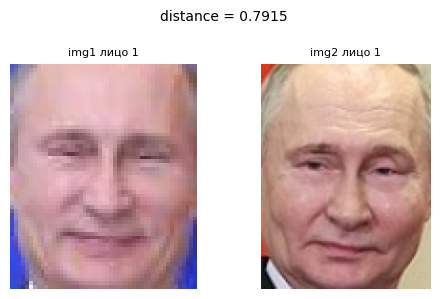

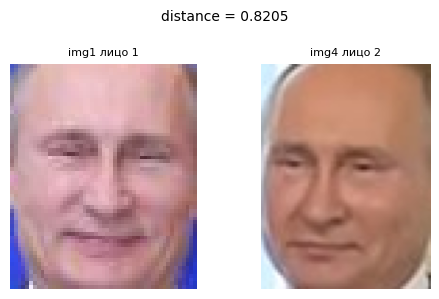

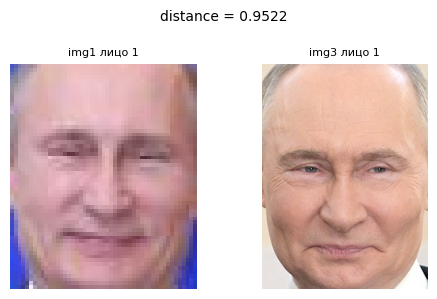

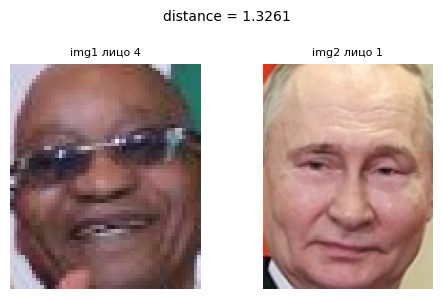

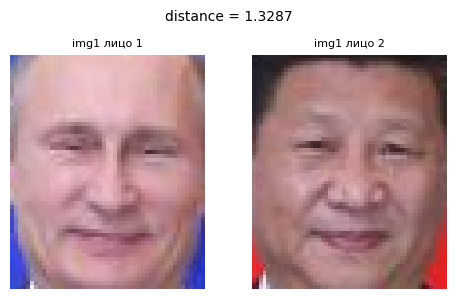

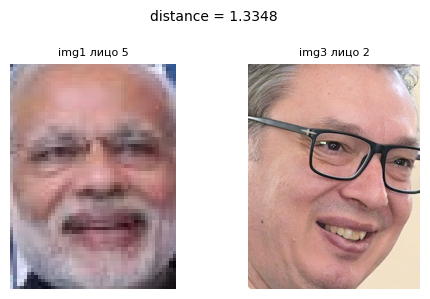

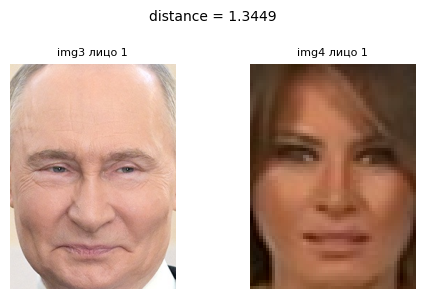

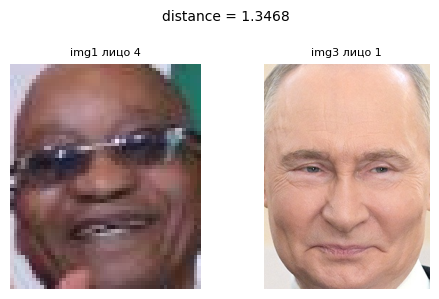

In [ ]:
from numpy.linalg import norm
import matplotlib.pyplot as plt
import numpy as np

for f in all_faces:
    emb = f["face_obj"].embedding
    f["embedding"] = emb / norm(emb)

similar_pairs = []
threshold = 1.35

for i in range(len(all_faces)):
    for j in range(i + 1, len(all_faces)):
        e1 = all_faces[i]["embedding"]
        e2 = all_faces[j]["embedding"]
        dist = norm(e1 - e2)
        if dist < threshold:
            similar_pairs.append((i, j, dist))

print(f"Найдено похожих пар: {len(similar_pairs)}")

for i, j, dist in sorted(similar_pairs, key=lambda x: x[2]):
    face1 = all_faces[i]["face"]
    face2 = all_faces[j]["face"]
    label1 = f"img{all_faces[i]['img_index']} лицо {all_faces[i]['face_index']}"
    label2 = f"img{all_faces[j]['img_index']} лицо {all_faces[j]['face_index']}"

    fig, axs = plt.subplots(1, 2, figsize=(5, 3))
    axs[0].imshow(face1)
    axs[0].axis("off")
    axs[0].set_title(label1, fontsize=8)

    axs[1].imshow(face2)
    axs[1].axis("off")
    axs[1].set_title(label2, fontsize=8)

    plt.suptitle(f"distance = {dist:.4f}", fontsize=10)
    plt.tight_layout()
    plt.show()

Тестирование библиотеки InsightFace успешно завершено

Face Recognition

Ссылка: GitHub: https://github.com/ageitgey/face_recognition

Возможности:

-    Простой API на базе dlib
-    Верификация и идентификация
-    Поддержка batch-инференса
-    Легко использовать для небольших задач и хобби-проектов

Преимущества:

-    Можно использовать даже без глубоких знаний ML
-    Прост в использовании

Требования:

- PyTorch / TensorFlow / MXNet — в зависимости от backend
- Поддержка CUDA (опционально)

Тестируем Face recognition

Тестирование показало, что библиотека face_recognition имеет существенные конфликты с Google Colab, связанные с её зависимостью от dlib.

Основные проблемы:

 - dlib не поддерживает GPU на Colab без ручной пересборки
 - ручная пересборка dlib под GPU или CPU нестабильна и часто приводит к ошибкам или зависанию
 - Даже при успешной сборке под CPU производительность будет низкой.


 Поэтому предпочтительнее использовать InsightFace или DeepFace, которые не зависят от dlib и корректно работают с GPU в Colab.

Выводы:

Библиотеки InsightFace и DeepFace продемонстрировали стабильную и корректную работу в среде Google Colab, обеспечивая высокую производительность, GPU-ускорение и схожие результаты распознавания лиц.

Библиотека Face Recognition показала низкую совместимость с Colab из-за нестабильной сборки и ограничений библиотеки dlib. Использование данной библиотеки не рекомендуется.